In [29]:
# Import modules

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"   # must happen before importing jax
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"  # must happen before importing jax

import argparse
import jax
import numpy as np
import numpyro
from numpyro.infer import Predictive, MCMC, NUTS
import jax.numpy as jnp
from helper import import_dataset, plot_utterance_distribution, plot_empirical_by_condition_distribution, plot_predictive_by_condition_distribution
from modelSpecification import likelihood_function_global_speaker, likelihood_function_incremental_speaker, global_speaker, incremental_speaker, incremental_semantics_jax
from modelSpecification import jitted_global_speaker, jitted_speaker
import matplotlib.pyplot as plt
import seaborn as sns
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)
print(jax.__version__)
print(jax.devices())


0.4.20
[CpuDevice(id=0)]


# Posterior analysis with incremental speaker (population-level)

In [36]:
import arviz as az
inference_data_file_path = "./inference_data/mcmc_results_incremental_speaker_warmup500_samples500_chains4.nc"
idata = az.from_netcdf(inference_data_file_path)
print(az.summary(idata))
idata
# ── Extract variable names dynamically from the posterior group ──────────────  
varnames = list(idata.posterior.data_vars)  
print("Inferred variable names:", varnames)  

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     2.158  0.059   2.044    2.266      0.002    0.001    1434.0   
log_beta -0.404  0.038  -0.475   -0.332      0.001    0.001    1495.0   

          ess_tail  r_hat  
alpha       1302.0    1.0  
log_beta    1199.0    1.0  
Inferred variable names: ['alpha', 'log_beta']


## Autocorrelation analysis

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'log_beta\n0'}>,
        <Axes: title={'center': 'log_beta\n1'}>,
        <Axes: title={'center': 'log_beta\n2'}>,
        <Axes: title={'center': 'log_beta\n3'}>]], dtype=object)

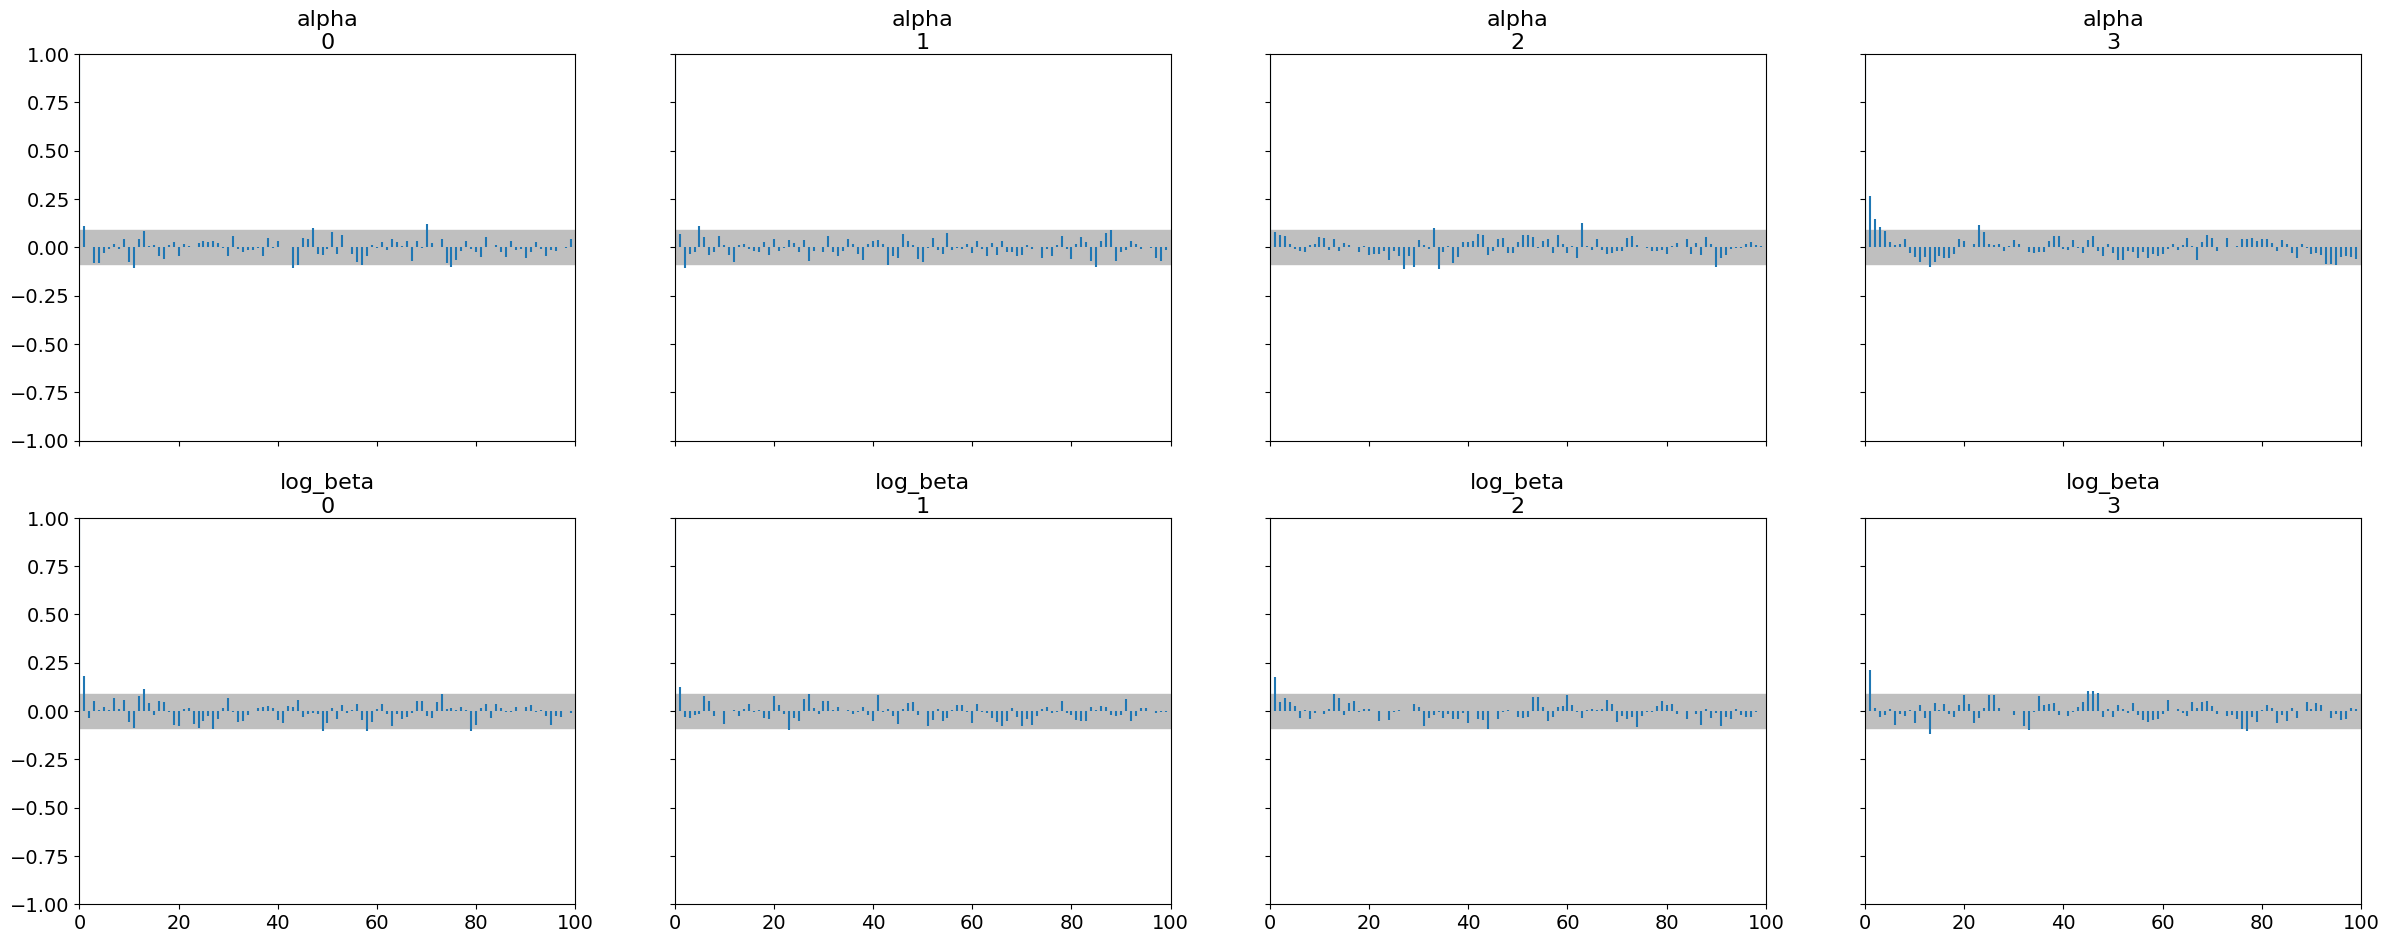

In [37]:

az.plot_autocorr(idata, var_names=varnames)


## Plot correlations between parameters

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='log_beta'>, <Axes: >]],
      dtype=object)

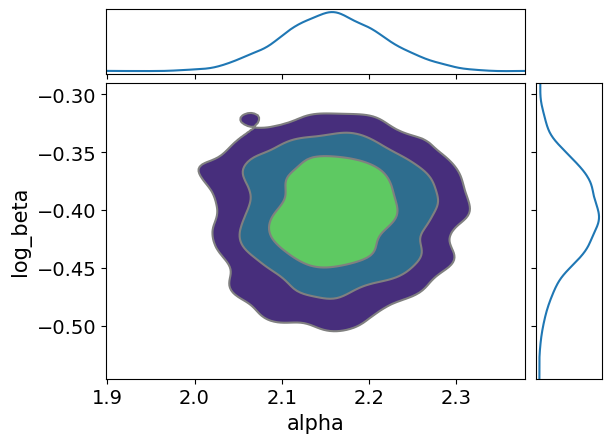

In [38]:
az.plot_pair(
    idata,
    var_names=varnames,
    kind="kde",
    marginals=True
)

## Plot prior vs posterior

array([[<Axes: >, <Axes: >, <Axes: xlabel='alpha'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='log_beta'>]], dtype=object)

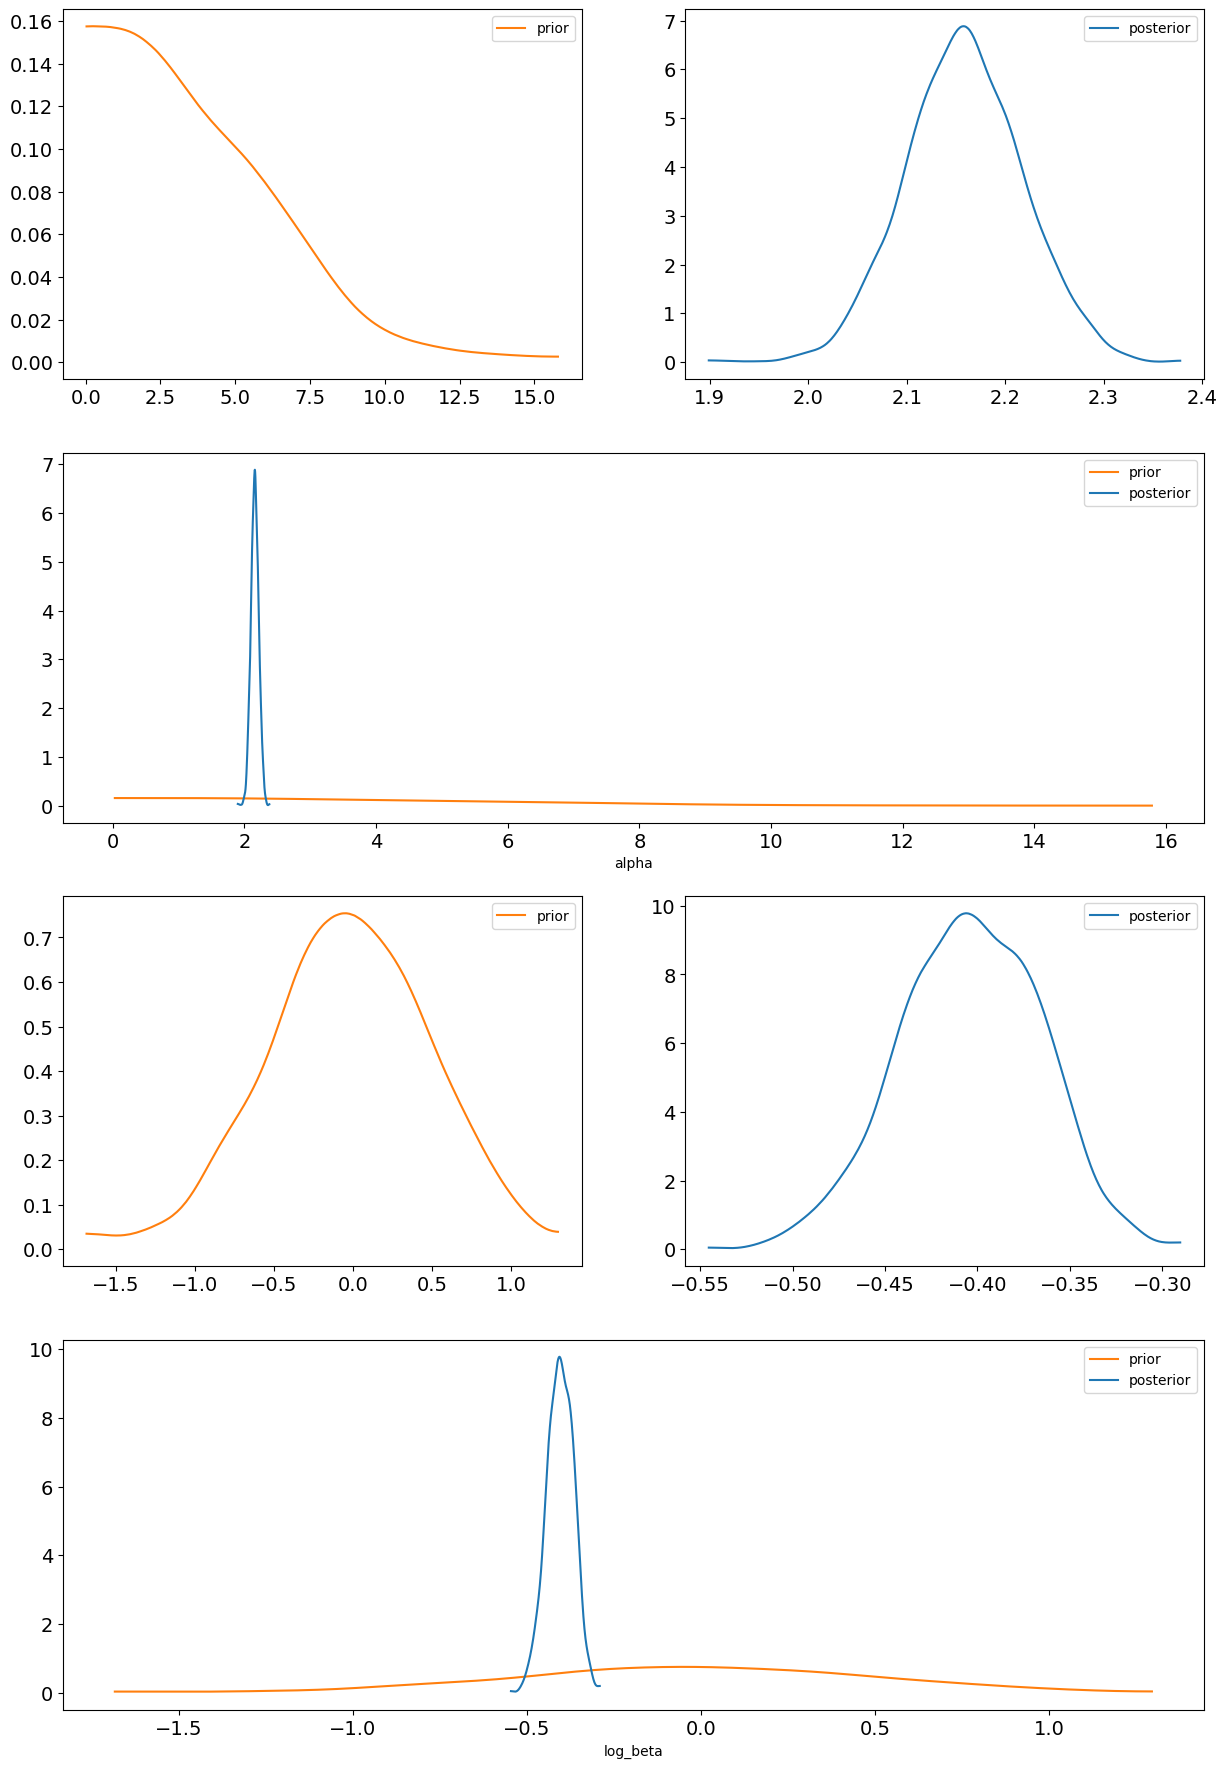

In [39]:
az.plot_dist_comparison(
    idata,
    var_names=varnames,
)

## Plot traces

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'log_beta'}>,
        <Axes: title={'center': 'log_beta'}>]], dtype=object)

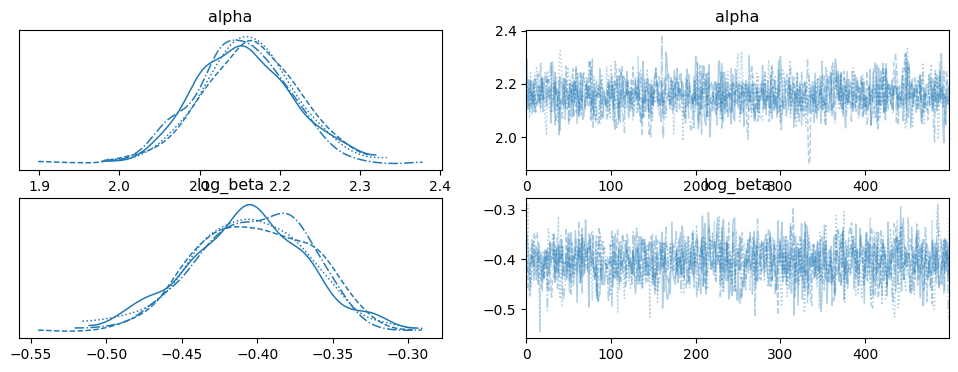

In [40]:
az.plot_trace(idata)

## Plot prior predictive, empirical, and posterior predictive distribution

Empirical Distribution by Condition


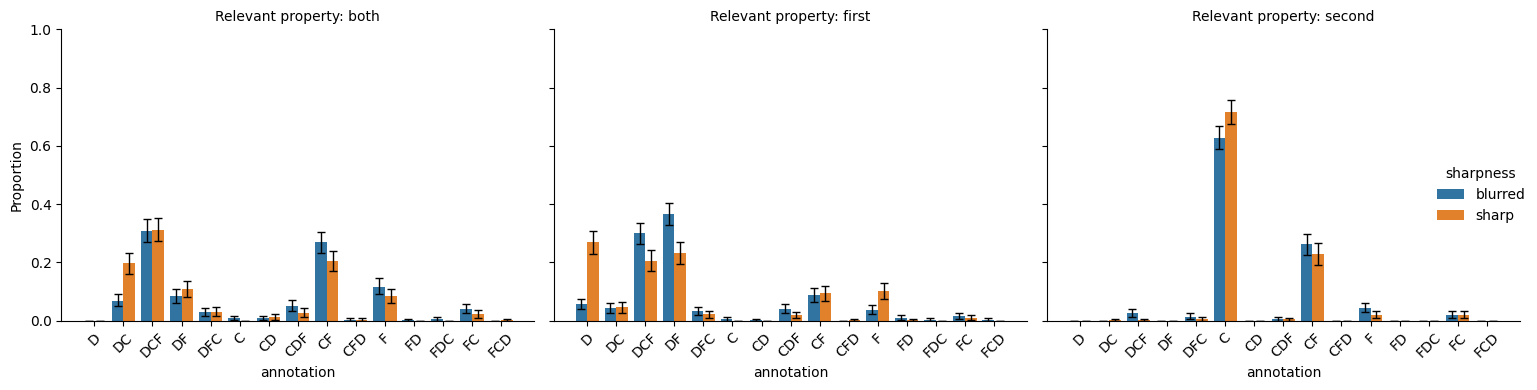

Posterior Predictive Distribution by Condition


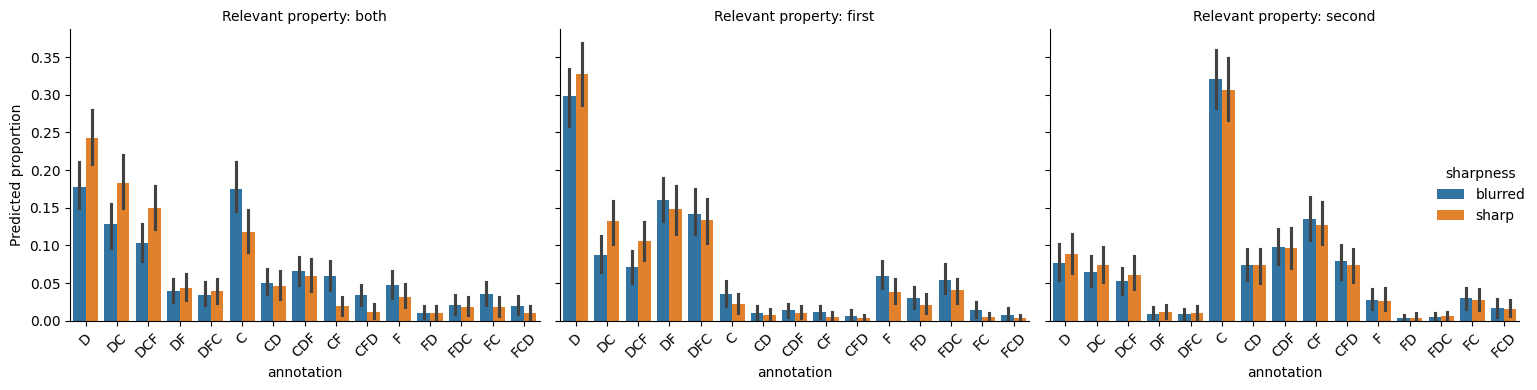

In [41]:
prior_predictive = idata.prior_predictive["obs"][0]
posterior_predictive = idata.posterior_predictive["obs"][0]

# Print titles for each plot
print("Empirical Distribution by Condition")
plot_empirical_by_condition_distribution()
#print("Prior Predictive Distribution by Condition")
#plot_predictive_by_condition_distribution(prior_predictive)
print("Posterior Predictive Distribution by Condition")
plot_predictive_by_condition_distribution(posterior_predictive)

# Posterior analysis with global speaker (population-level)

In [1]:
import arviz as az
inference_data_file_path = "./inference_data/mcmc_results_global_speaker_warmup500_samples500_chains4.nc"
idata = az.from_netcdf(inference_data_file_path)
print(az.summary(idata))
idata
# ── Extract variable names dynamically from the posterior group ──────────────  
varnames = list(idata.posterior.data_vars)  
print("Inferred variable names:", varnames)  

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha     1.140  0.065   1.024    1.263      0.002    0.002    1024.0   
log_beta -0.173  0.029  -0.227   -0.118      0.001    0.001    1387.0   

          ess_tail  r_hat  
alpha       1102.0    1.0  
log_beta     907.0    1.0  
Inferred variable names: ['alpha', 'log_beta']


## Plot autocorrelation

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'log_beta\n0'}>,
        <Axes: title={'center': 'log_beta\n1'}>,
        <Axes: title={'center': 'log_beta\n2'}>,
        <Axes: title={'center': 'log_beta\n3'}>]], dtype=object)

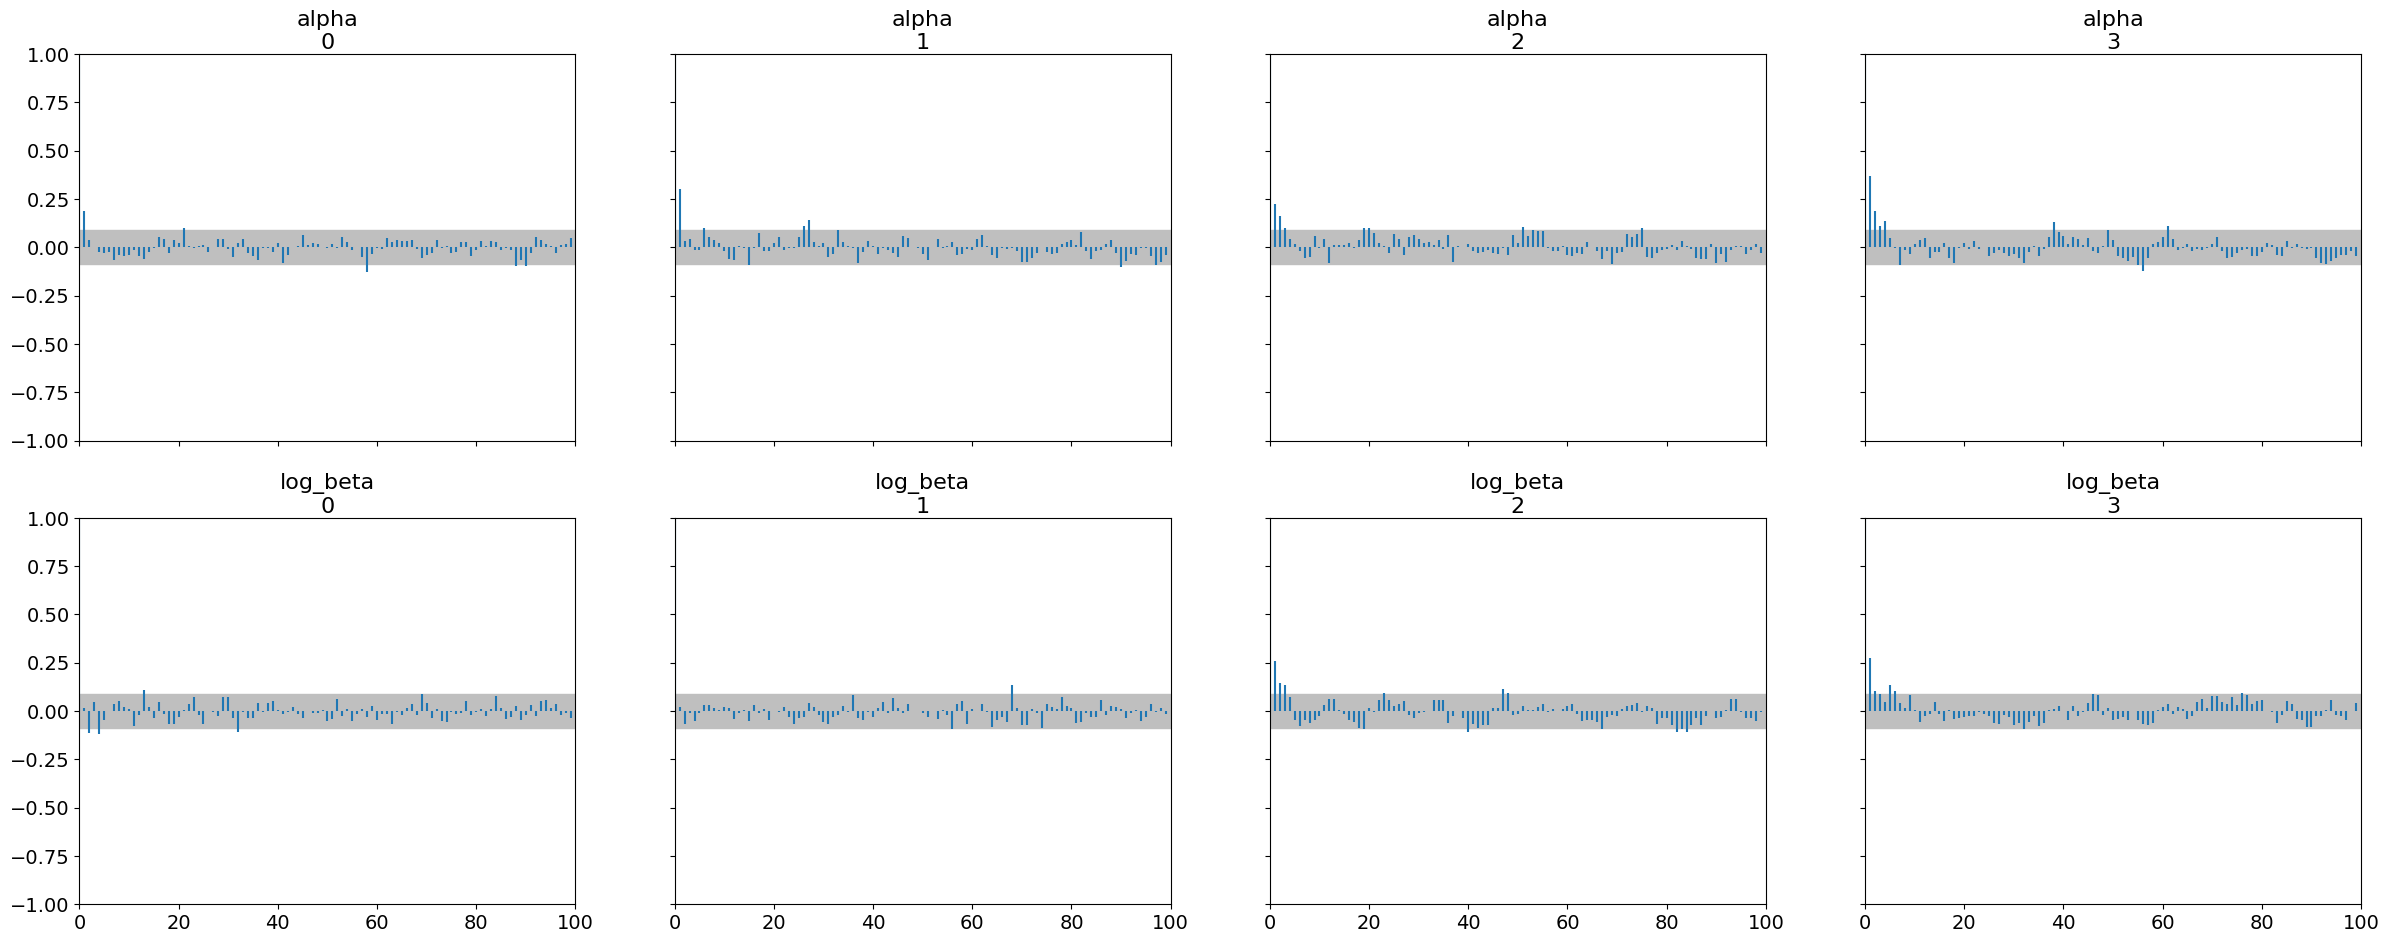

In [2]:
az.plot_autocorr(idata, var_names=varnames)

## Plot correlation

array([[<Axes: >, None],
       [<Axes: xlabel='alpha', ylabel='log_beta'>, <Axes: >]],
      dtype=object)

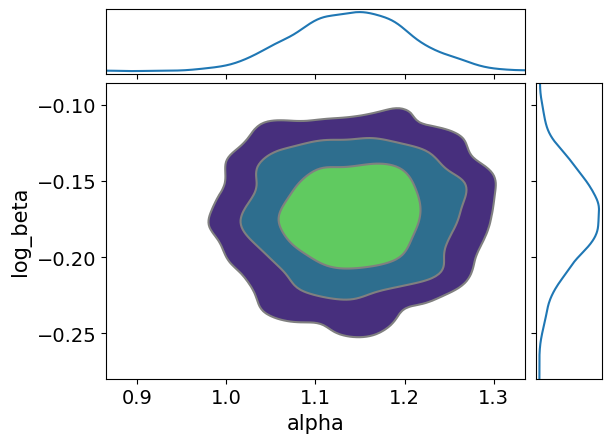

In [3]:
az.plot_pair(
    idata,
    var_names=varnames,
    kind="kde",
    marginals=True
)

## Plot posterior vs prior

array([[<Axes: >, <Axes: >, <Axes: xlabel='alpha'>],
       [<Axes: >, <Axes: >, <Axes: xlabel='log_beta'>]], dtype=object)

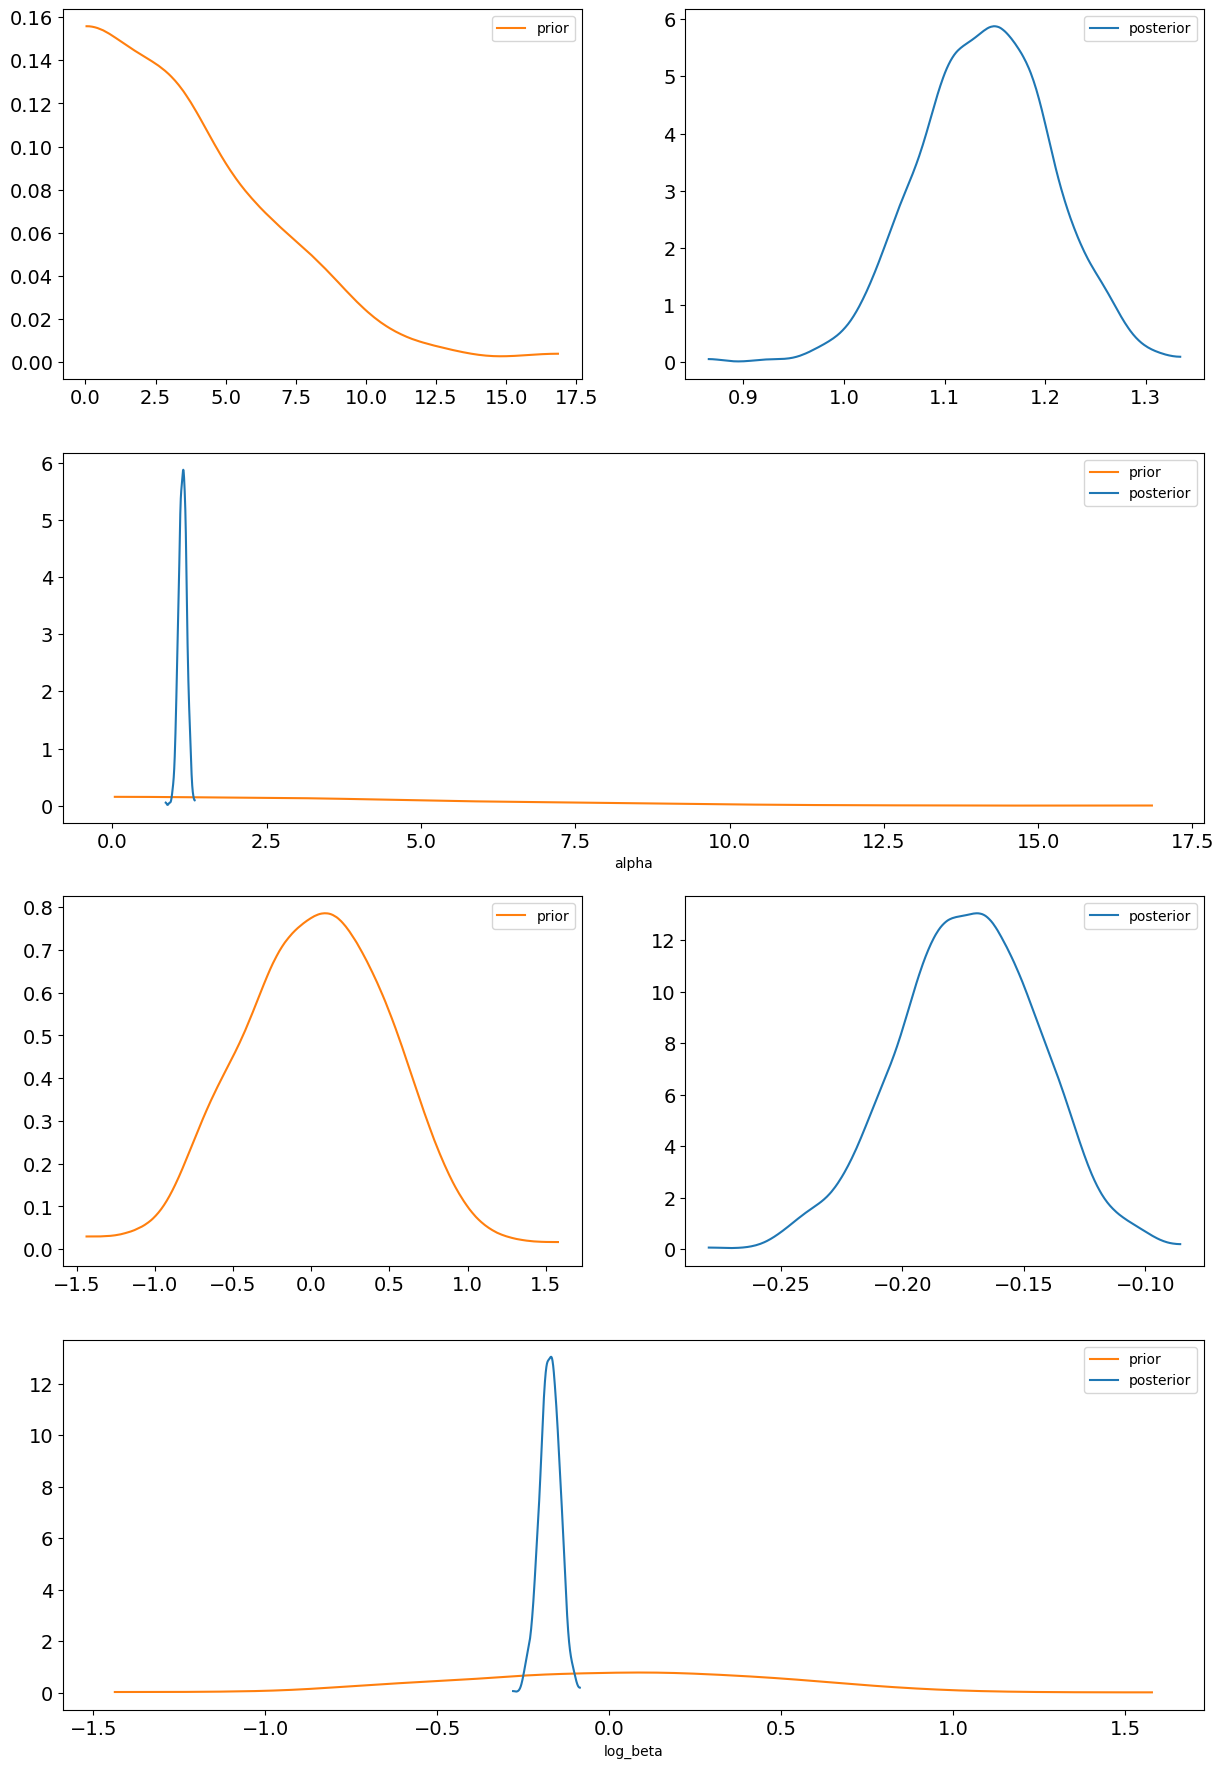

In [4]:
az.plot_dist_comparison(
    idata,
    var_names=varnames,
)

## Plot trace


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'log_beta'}>,
        <Axes: title={'center': 'log_beta'}>]], dtype=object)

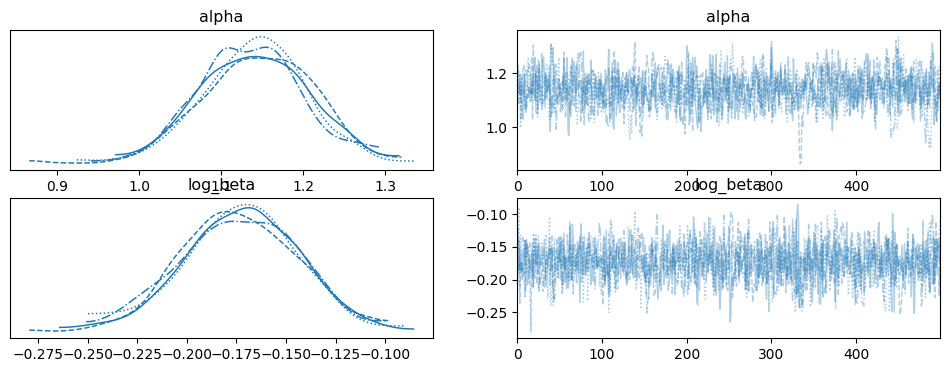

In [5]:
az.plot_trace(idata)

## Posterior predictive plot

Empirical Distribution by Condition


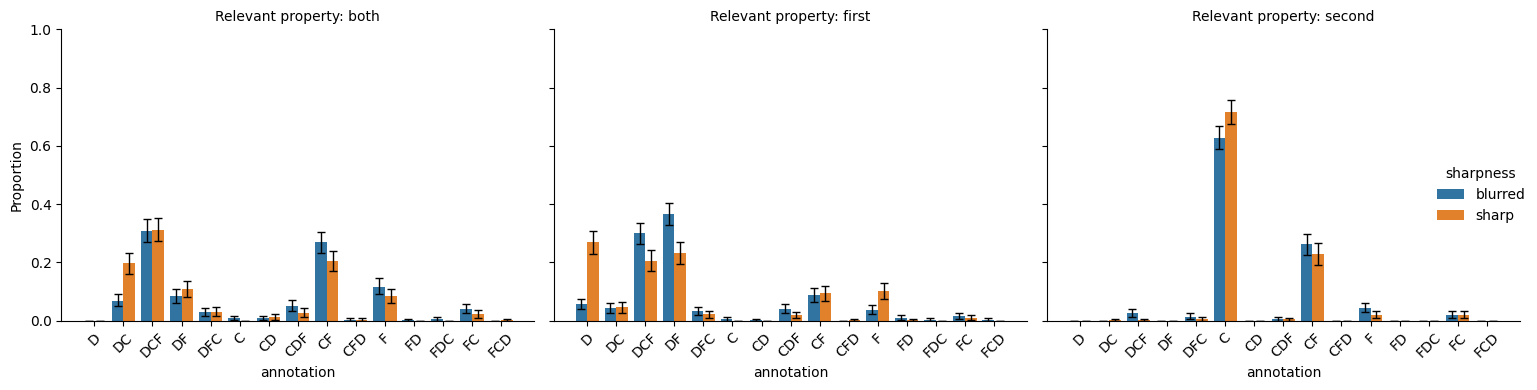

Posterior Predictive Distribution by Condition


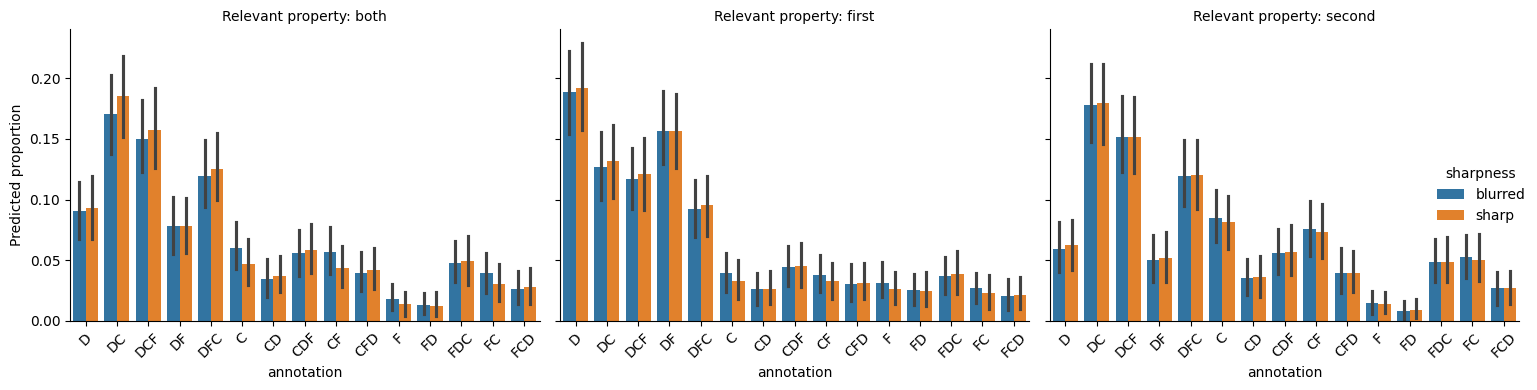

In [8]:
prior_predictive = idata.prior_predictive["obs"][0]
posterior_predictive = idata.posterior_predictive["obs"][0]

# Print titles for each plot
print("Empirical Distribution by Condition")
plot_empirical_by_condition_distribution()
#print("Prior Predictive Distribution by Condition")
#plot_predictive_by_condition_distribution(prior_predictive)
print("Posterior Predictive Distribution by Condition")
plot_predictive_by_condition_distribution(posterior_predictive)

## Model comparison

In [44]:
import arviz as az  
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import matplotlib.gridspec as gridspec  

# ── Load ──────────────────────────────────────────────────────────────────────  
inc_name_last = "./inference_data/mcmc_results_incremental_speaker_last.nc"
glob_name_last = "./inference_data/mcmc_results_global_speaker_last.nc"
inc_name_chains4 = "./inference_data/mcmc_results_incremental_speaker_warmup500_samples500_chains4.nc"
glob_name_chains4 = "./inference_data/mcmc_results_global_speaker_warmup500_samples500_chains4.nc"
idata_inc = az.from_netcdf(inc_name_chains4)  
idata_glob = az.from_netcdf(glob_name_chains4)  
# ── Compute LOO for each model ────────────────────────────────────────────────
#    LOO = Leave-One-Out cross-validation via PSIS
#    More reliable than WAIC for finite samples

loo_inc  = az.loo(idata_inc,  var_name="obs", pointwise=True)
loo_glob = az.loo(idata_glob, var_name="obs", pointwise=True)

print("=== LOO: Incremental ===")
print(loo_inc)
print("\n=== LOO: Global ===")
print(loo_glob)

# Key output fields:
#
#   elpd_loo    : expected log pointwise predictive density
#                 HIGHER = better predictive accuracy
#   p_loo       : effective number of parameters
#                 if p_loo >> n_params → model is overfit / misspecified
#   looic       : -2 * elpd_loo  (like AIC scale, LOWER = better)
#   se          : standard error of elpd_loo
#   warning     : True if any Pareto k̂ > 0.7
#
#   Pareto k̂ interpretation:
#     k̂ < 0.5   : excellent  ✅
#     k̂ < 0.7   : good       ✅
#     k̂ < 1.0   : bad        ⚠️  → importance weights unreliable
#     k̂ ≥ 1.0   : very bad   ❌  → LOO invalid for those points




=== LOO: Incremental ===
Computed from 2000 posterior samples and 3196 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7149.50    57.64
p_loo        1.89        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3196  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%


=== LOO: Global ===
Computed from 2000 posterior samples and 3196 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -7844.95    35.25
p_loo        1.30        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     3196  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [45]:
# ── Compare models ────────────────────────────────────────────────────────────
comparison = az.compare(
    {
        "incremental": idata_inc,
        "global":      idata_glob,
    },
    ic      = "loo",        # or "waic" — LOO preferred
    method  = "stacking",   # "stacking" or "BB-pseudo-BMA"
    var_name= "obs",
)

print(comparison)

# Output table columns:
#
#   rank      : 0 = best model
#   elpd_loo  : higher is better
#   p_loo     : effective parameters
#   elpd_diff : difference from best model (best = 0.0)
#   weight    : stacking weight ∈ [0, 1], sums to 1
#   se        : se of elpd_loo
#   dse       : se of elpd_diff (use THIS for significance, not se)
#   warning   : Pareto k̂ issues present?
#
# ── Significance rule of thumb ────────────────────────────────────────────────
#   |elpd_diff| > 2 * dse   → meaningful difference
#   |elpd_diff| < 2 * dse   → models indistinguishable by LOO

best = comparison.index[0]
diff  = comparison["elpd_diff"].iloc[1]
dse   = comparison["dse"].iloc[1]
ratio = abs(diff) / dse if dse > 0 else float("inf")

print(f"\nBest model : {best}")
print(f"elpd_diff  : {diff:.2f}")
print(f"dse        : {dse:.2f}")
print(f"|diff|/dse : {ratio:.2f}  {'← meaningful' if ratio > 2 else '← not significant'}")


             rank     elpd_loo     p_loo   elpd_diff    weight         se  \
incremental     0 -7149.503589  1.888246    0.000000  0.849658  57.638319   
global          1 -7844.947933  1.297655  695.444345  0.150342  35.248300   

                   dse  warning scale  
incremental   0.000000    False   log  
global       46.543304    False   log  

Best model : incremental
elpd_diff  : 695.44
dse        : 46.54
|diff|/dse : 14.94  ← meaningful


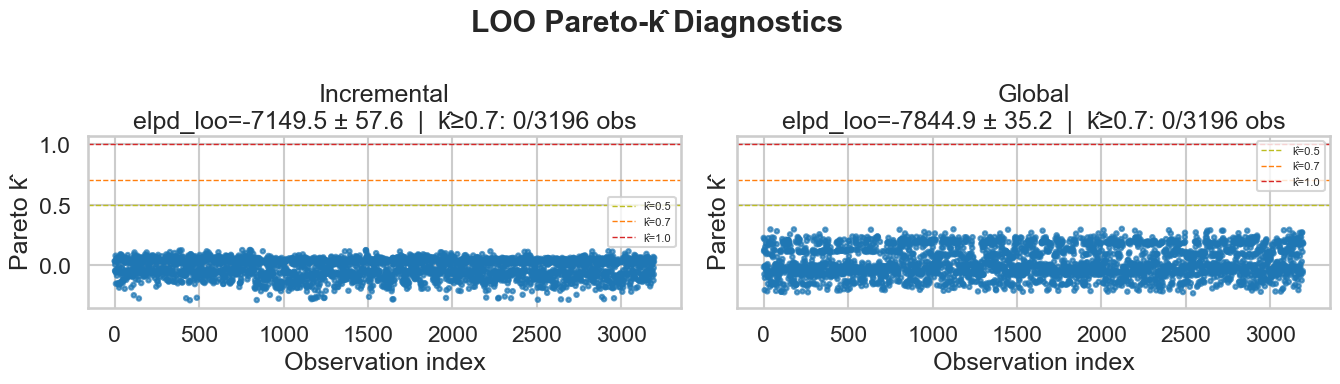

In [46]:
# ── Pareto k̂ per observation ─────────────────────────────────────────────────
# Tells you WHERE each model struggles

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (name, idata, loo) in zip(axes, [
    ("Incremental", idata_inc,  loo_inc),
    ("Global",      idata_glob, loo_glob),
]):
    k_vals = loo.pareto_k.values                              # (N,)
    n_obs  = len(k_vals)
    colors = np.where(k_vals >= 1.0, "#d62728",   # very bad
             np.where(k_vals >= 0.7, "#ff7f0e",   # bad
             np.where(k_vals >= 0.5, "#bcbd22",   # ok
                                     "#1f77b4"))) # good

    ax.scatter(np.arange(n_obs), k_vals, c=colors, s=10, alpha=0.7)
    ax.axhline(0.5, color="#bcbd22", ls="--", lw=1, label="k̂=0.5")
    ax.axhline(0.7, color="#ff7f0e", ls="--", lw=1, label="k̂=0.7")
    ax.axhline(1.0, color="#d62728", ls="--", lw=1, label="k̂=1.0")

    n_bad = np.sum(k_vals >= 0.7)
    ax.set_title(
        f"{name}\n"
        f"elpd_loo={loo.elpd_loo:.1f} ± {loo.se:.1f}  |  "
        f"k̂≥0.7: {n_bad}/{n_obs} obs"
    )
    ax.set_xlabel("Observation index")
    ax.set_ylabel("Pareto k̂")
    ax.legend(fontsize=8)

plt.suptitle("LOO Pareto-k̂ Diagnostics", fontweight="bold")
plt.tight_layout()
plt.show()


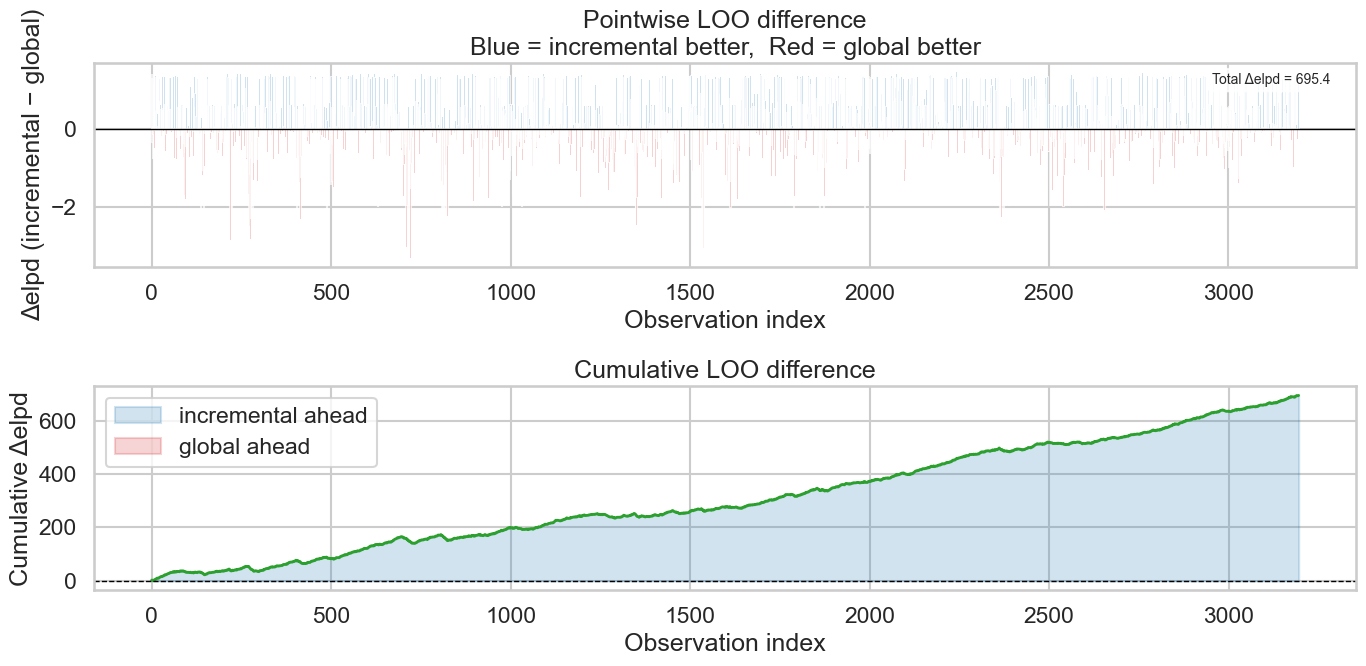

In [47]:
# ── Per-observation: which model wins where? ──────────────────────────────────
# pointwise elpd_diff > 0  → incremental better on that trial
# pointwise elpd_diff < 0  → global better on that trial

pw_inc  = loo_inc.loo_i.values                               # (N,)
pw_glob = loo_glob.loo_i.values                              # (N,)
pw_diff = pw_inc - pw_glob                                   # (N,)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Top: pointwise difference ─────────────────────────────────────────────────
ax = axes[0]
colors = np.where(pw_diff > 0, "#1f77b4", "#d62728")
ax.bar(np.arange(len(pw_diff)), pw_diff, color=colors, width=1.0, alpha=0.7)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("Observation index")
ax.set_ylabel("Δelpd (incremental − global)")
ax.set_title(
    "Pointwise LOO difference\n"
    "Blue = incremental better,  Red = global better"
)

# Annotate total
total_diff = pw_diff.sum()
ax.text(0.98, 0.95, f"Total Δelpd = {total_diff:.1f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# ── Bottom: cumulative difference ─────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(np.cumsum(pw_diff), color="#2ca02c", lw=2)
ax2.axhline(0, color="black", lw=1, ls="--")
ax2.fill_between(np.arange(len(pw_diff)), np.cumsum(pw_diff), 0,
                 where=np.cumsum(pw_diff) > 0,
                 color="#1f77b4", alpha=0.2, label="incremental ahead")
ax2.fill_between(np.arange(len(pw_diff)), np.cumsum(pw_diff), 0,
                 where=np.cumsum(pw_diff) < 0,
                 color="#d62728", alpha=0.2, label="global ahead")
ax2.set_xlabel("Observation index")
ax2.set_ylabel("Cumulative Δelpd")
ax2.set_title("Cumulative LOO difference")
ax2.legend()

plt.tight_layout()
plt.show()


In [48]:
# ── Summary report ────────────────────────────────────────────────────────────
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison.to_string())
print()

for name, loo in [("Incremental", loo_inc), ("Global", loo_glob)]:
    k = loo.pareto_k.values
    print(f"{name}:")
    print(f"  elpd_loo = {loo.elpd_loo:.2f} ± {loo.se:.2f}")
    print(f"  p_loo    = {loo.p_loo:.2f}")
    print(f"  k̂ < 0.5  : {(k < 0.5).sum()} obs  (good)")
    print(f"  k̂ ∈[0.5, 0.7): {((k>=0.5)&(k<0.7)).sum()} obs  (ok)")
    print(f"  k̂ ∈[0.7, 1.0): {((k>=0.7)&(k<1.0)).sum()} obs  (bad ⚠️)")
    print(f"  k̂ ≥ 1.0  : {(k >= 1.0).sum()} obs  (very bad ❌)")
    print()

# ── Decision table ────────────────────────────────────────────────────────────
print("""
Result               Interpretation
─────────────────────────────────────────────────────────────
|elpd_diff| < 2*dse  Models equivalent — incremental adds no
                     predictive value over global

|elpd_diff| > 2*dse  
  incremental wins   Incremental processing matters for fit
  global wins        Global speaker is sufficient / simpler
  
p_loo >> n_params    Model overfit or misspecified
  (e.g. p_loo > 5    (only 2 free params: phi_color, phi_form)
   for 2-param model)

weight ≈ 1.0         One model dominates stacking ensemble
weight ≈ 0.5/0.5     Models equally predictive — consider
                     averaging predictions
""")


MODEL COMPARISON SUMMARY
             rank     elpd_loo     p_loo   elpd_diff    weight         se        dse  warning scale
incremental     0 -7149.503589  1.888246    0.000000  0.849658  57.638319   0.000000    False   log
global          1 -7844.947933  1.297655  695.444345  0.150342  35.248300  46.543304    False   log

Incremental:
  elpd_loo = -7149.50 ± 57.64
  p_loo    = 1.89
  k̂ < 0.5  : 3196 obs  (good)
  k̂ ∈[0.5, 0.7): 0 obs  (ok)
  k̂ ∈[0.7, 1.0): 0 obs  (bad ⚠️)
  k̂ ≥ 1.0  : 0 obs  (very bad ❌)

Global:
  elpd_loo = -7844.95 ± 35.25
  p_loo    = 1.30
  k̂ < 0.5  : 3196 obs  (good)
  k̂ ∈[0.5, 0.7): 0 obs  (ok)
  k̂ ∈[0.7, 1.0): 0 obs  (bad ⚠️)
  k̂ ≥ 1.0  : 0 obs  (very bad ❌)


Result               Interpretation
─────────────────────────────────────────────────────────────
|elpd_diff| < 2*dse  Models equivalent — incremental adds no
                     predictive value over global

|elpd_diff| > 2*dse  
  incremental wins   Incremental processing matters for fit
  gl

## Generate a correlation plot with model predictions and empirical data

Pearson r  : 0.681
Spearman ρ : 0.537
Calibration: y = 0.375x + 0.039 (R² = 0.464)


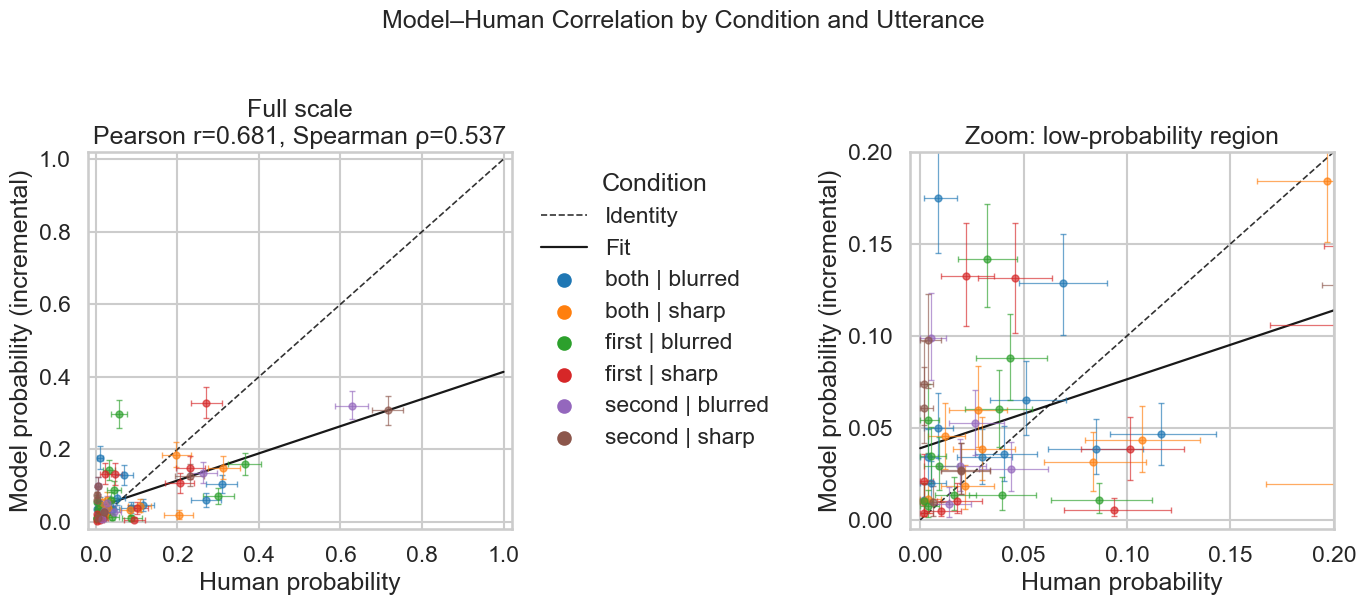

In [43]:
# Correlation plot: incremental model predictions vs human data (with uncertainty)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import arviz as az

# --- Load best model posterior predictive (incremental) ---
if "idata_inc" not in globals():
    inc_name_chains4 = "./inference_data/mcmc_results_incremental_speaker_warmup500_samples500_chains4.nc"
    idata_inc = az.from_netcdf(inc_name_chains4)

# --- Human data ---
data = import_dataset()
df = data["df"].copy()
group_cols = ["relevant_property", "sharpness"]
all_codes = sorted(df["annotation_seq_flat"].unique())

human_counts = (
    df.groupby(group_cols + ["annotation_seq_flat"]).size().rename("count").reset_index()
 )
human_totals = df.groupby(group_cols).size().rename("n_total").reset_index()
human_summary = human_counts.merge(human_totals, on=group_cols, how="left")
human_summary["human_mean"] = human_summary["count"] / human_summary["n_total"]

# Bootstrap CI for human probabilities
rng = np.random.default_rng(431)
n_boot = 1000
boot_records = []
for cond_vals, sub in df.groupby(group_cols):
    labels = sub["annotation_seq_flat"].to_numpy()
    n = len(labels)
    for b in range(n_boot):
        sample = rng.choice(labels, size=n, replace=True)
        for code in all_codes:
            boot_records.append((*cond_vals, code, np.mean(sample == code)))

boot_df = pd.DataFrame(
    boot_records,
    columns=["relevant_property", "sharpness", "annotation_seq_flat", "p_boot"]
 )
human_ci = (
    boot_df.groupby(group_cols + ["annotation_seq_flat"])["p_boot"]
    .agg(
        human_low=lambda x: np.percentile(x, 2.5),
        human_high=lambda x: np.percentile(x, 97.5),
    )
    .reset_index()
 )
human_summary = human_summary.merge(human_ci, on=group_cols + ["annotation_seq_flat"], how="left")

# --- Model predictions from posterior predictive draws ---
obs = idata_inc.posterior_predictive["obs"]
if hasattr(obs, "stack") and "chain" in obs.dims and "draw" in obs.dims:
    pred_draws = obs.stack(sample=("chain", "draw")).transpose("sample", "item").values
elif hasattr(obs, "dims") and "draw" in obs.dims:
    pred_draws = obs.transpose("draw", "item").values
else:
    pred_draws = np.asarray(obs)

cond_df = df[group_cols].reset_index(drop=True)
model_records = []
n_draws = pred_draws.shape[0]
for d in range(n_draws):
    tmp = cond_df.copy()
    tmp["annotation_seq_flat"] = pred_draws[d, :]
    counts = (
        tmp.groupby(group_cols + ["annotation_seq_flat"]).size().rename("n").reset_index()
    )
    totals = tmp.groupby(group_cols).size().rename("n_total").reset_index()
    out = counts.merge(totals, on=group_cols, how="left")
    out["p"] = out["n"] / out["n_total"]
    out["draw"] = d
    model_records.append(out[group_cols + ["annotation_seq_flat", "draw", "p"]])

model_df = pd.concat(model_records, ignore_index=True)
model_summary = (
    model_df.groupby(group_cols + ["annotation_seq_flat"])["p"]
    .agg(
        model_mean="mean",
        model_low=lambda x: np.percentile(x, 2.5),
        model_high=lambda x: np.percentile(x, 97.5),
    )
    .reset_index()
 )

# --- Merge + labels ---
plot_df = human_summary.merge(model_summary, on=group_cols + ["annotation_seq_flat"], how="inner")
flat_to_cat = {
    0: "D", 1: "DC", 2: "DCF", 3: "DF", 4: "DFC",
    5: "C", 6: "CD", 7: "CDF", 8: "CF", 9: "CFD",
    10: "F", 11: "FD", 12: "FDC", 13: "FC", 14: "FCD",
}
plot_df["annotation"] = plot_df["annotation_seq_flat"].map(flat_to_cat)
plot_df["condition"] = plot_df["relevant_property"].astype(str) + " | " + plot_df["sharpness"].astype(str)

# --- Correlation + calibration summary ---
x = plot_df["human_mean"].to_numpy()
y = plot_df["model_mean"].to_numpy()
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r = np.corrcoef(pd.Series(x).rank(), pd.Series(y).rank())[0, 1]
slope, intercept = np.polyfit(x, y, 1)
y_hat = slope * x + intercept
r2 = 1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Pearson r  : {pearson_r:.3f}")
print(f"Spearman ρ : {spearman_r:.3f}")
print(f"Calibration: y = {slope:.3f}x + {intercept:.3f} (R² = {r2:.3f})")

# --- Paper-style plot: full + zoom panel ---
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)
ax_full, ax_zoom = axes

palette = sns.color_palette("tab10", n_colors=plot_df["condition"].nunique())
cond_to_color = {c: palette[i] for i, c in enumerate(sorted(plot_df["condition"].unique()))}

def draw_points(ax):
    # identity line
    ax.plot([0, 1], [0, 1], ls="--", lw=1.2, color="black", alpha=0.8, label="Identity")
    # calibration line
    xs = np.linspace(0, 1, 200)
    ax.plot(xs, slope * xs + intercept, color="black", lw=1.6, alpha=0.9, label="Fit")

    for _, row in plot_df.iterrows():
        c = cond_to_color[row["condition"]]
        xx = row["human_mean"]
        yy = row["model_mean"]
        xerr = [[xx - row["human_low"]], [row["human_high"] - xx]]
        yerr = [[yy - row["model_low"]], [row["model_high"] - yy]]
        ax.errorbar(
            xx, yy,
            xerr=xerr, yerr=yerr,
            fmt="o", ms=5,
            color=c, ecolor=c, elinewidth=0.9, capsize=2, alpha=0.65,
        )

draw_points(ax_full)
draw_points(ax_zoom)

# full panel
ax_full.set_xlim(-0.02, 1.02)
ax_full.set_ylim(-0.02, 1.02)
ax_full.set_title(f"Full scale\nPearson r={pearson_r:.3f}, Spearman ρ={spearman_r:.3f}")
ax_full.set_xlabel("Human probability")
ax_full.set_ylabel("Model probability (incremental)")

# zoom panel for dense near-zero region
zoom_max = 0.20
ax_zoom.set_xlim(-0.005, zoom_max)
ax_zoom.set_ylim(-0.005, zoom_max)
ax_zoom.set_title("Zoom: low-probability region")
ax_zoom.set_xlabel("Human probability")
ax_zoom.set_ylabel("Model probability (incremental)")

# condition legend (single shared)
for cond, c in cond_to_color.items():
    ax_full.scatter([], [], color=c, label=cond)
ax_full.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

fig.suptitle("Model–Human Correlation by Condition and Utterance", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

# Posterior analysis with model comparison (population-level)

# Posterior analysis with incremental speaker (hierarchical-level)

# Posterior analysis with global speaker (hierarchical-level)

In [28]:
# Quick runtime benchmark: global vs incremental forward pass (exact vs fast)
import time
import jax.numpy as jnp
import importlib
import modelSpecification as ms

# Ensure notebook sees latest code edits
ms = importlib.reload(ms)
jitted_global = ms.jitted_global_speaker
jitted_incremental_exact = ms.jitted_speaker
jitted_incremental_fast = ms.jitted_speaker_frozen

data = import_dataset()
states = data["states_train"]
sharpness_idx = data["sharpness_idx"]
gamma = jnp.where(sharpness_idx > 0.5, 1.6, 1.0)

params = dict(
    alpha=3.0,
    color_semval=0.8,
    form_semval=0.7,
    k=0.5,
    wf=1.0,
    beta=1.0,
    gamma=gamma,
 )

# compile once
_ = jitted_global(states, **params).block_until_ready()
_ = jitted_incremental_exact(states, **params).block_until_ready()
_ = jitted_incremental_fast(states, **params).block_until_ready()

def benchmark(fn, n=6):
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        out = fn(states, **params)
        out.block_until_ready()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.min(times)), float(np.max(times))

g_mean, g_min, g_max = benchmark(jitted_global)
i_mean, i_min, i_max = benchmark(jitted_incremental_exact)
f_mean, f_min, f_max = benchmark(jitted_incremental_fast)

print(f"N trials: {states.shape[0]}")
print(f"Global            mean={g_mean:.4f}s min={g_min:.4f}s max={g_max:.4f}s")
print(f"Incremental exact mean={i_mean:.4f}s min={i_min:.4f}s max={i_max:.4f}s")
print(f"Incremental fast  mean={f_mean:.4f}s min={f_min:.4f}s max={f_max:.4f}s")
print(f"Ratio exact/global: {i_mean / g_mean:.2f}x")
print(f"Ratio fast/global : {f_mean / g_mean:.2f}x")
print(f"Speedup (exact/fast): {i_mean / f_mean:.2f}x")

0.4.20
[CpuDevice(id=0)]
N trials: 3196
Global            mean=0.0030s min=0.0028s max=0.0040s
Incremental exact mean=0.0306s min=0.0301s max=0.0310s
Incremental fast  mean=0.0265s min=0.0259s max=0.0272s
Ratio exact/global: 10.05x
Ratio fast/global : 8.70x
Speedup (exact/fast): 1.15x
